In [11]:
!pip install -q sentence-transformers umap-learn hdbscan bertopic gensim

In [12]:
import os
import re
import json
import time
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import openai
os.environ["OPENAI_API_KEY"] = ''
SEED = 42

# 1) Data Loading

In [13]:
# Load 20 Newsgroups with metadata stripped to avoid topic leakage
newsgroups = fetch_20newsgroups(
    subset="all",
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
)

raw_documents = newsgroups.data
true_labels = newsgroups.target
label_names = newsgroups.target_names

print(f"Total documents: {len(raw_documents)}")
print(f"True categories: {len(label_names)}")
print(f"Sample: {raw_documents[0][:200]}...")

Total documents: 18846
True categories: 20
Sample: 

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However,...


In [14]:
def clean_text(text: str) -> str:
    """Minimal cleaning: lowercase, remove non-alpha, collapse whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Clean all documents
documents = [clean_text(doc) for doc in raw_documents]

# Filter out very short documents (< 30 chars) that are likely noise
valid_mask = [len(doc) >= 30 for doc in documents]
documents = [d for d, v in zip(documents, valid_mask) if v]
true_labels_filtered = true_labels[[i for i, v in enumerate(valid_mask) if v]]

print(f"Documents after filtering: {len(documents)}")
print(f"Sample cleaned: {documents[0][:150]}...")

Documents after filtering: 18072
Sample cleaned: i am sure some bashers of pens fans are pretty confused about the lack of any kind of posts about the recent pens massacre of the devils actually i am...


# 2) Latent Dirichlet Allocation (LDA)

LDA is a **generative probabilistic model** that assumes each document is a mixture
of topics, and each topic is a mixture of words.

### The Generative Process
For each document $d$ in the corpus:
1. Draw a topic distribution $\theta_d \sim \text{Dir}(\alpha)$ — "what topics is this document about?"
2. For each word position $n$ in document $d$:
   - Draw a topic assignment $z_{d,n} \sim \text{Multinomial}(\theta_d)$
   - Draw a word $w_{d,n} \sim \text{Multinomial}(\phi_{z_{d,n}})$ from that topic's word distribution

Where each topic's word distribution is: $\phi_k \sim \text{Dir}(\beta)$

### Hyperparameters
- **$\alpha$** (doc-topic prior): Higher $\alpha$ → documents cover more topics uniformly.
  Lower $\alpha$ → documents focus on fewer topics. Typical: $\alpha = 1/K$
- **$\beta$** (topic-word prior): Higher $\beta$ → topics use more words uniformly.
  Lower $\beta$ → topics are concentrated on fewer words. Typical: $\beta = 1/K$


After integrating out $\theta$ and $\phi$, the conditional probability of
assigning topic $k$ to the $n$-th word in document $d$ is:

$$p(z_{d,n} = k \mid z_{-d,n}, w, \alpha, \beta) \propto
\underbrace{\frac{n_{d,k}^{-d,n} + \alpha}{n_{d,\cdot}^{-d,n} + K\alpha}}_{\text{document-topic}}
\cdot
\underbrace{\frac{n_{k,w}^{-d,n} + \beta}{n_{k,\cdot}^{-d,n} + V\beta}}_{\text{topic-word}}$$

Where:
- $n_{d,k}^{-d,n}$: count of words in doc $d$ assigned to topic $k$, **excluding** position $(d,n)$
- $n_{k,w}^{-d,n}$: count of word $w$ assigned to topic $k$ across all docs, **excluding** $(d,n)$
- $n_{d,\cdot}$: total word count in doc $d$; $n_{k,\cdot}$: total words assigned to topic $k$
- $K$: number of topics; $V$: vocabulary size

### Intuition for the Two Factors
1. **Document-topic** ($p(\text{topic } k \mid \text{document } d)$): If many other words in $d$
   are assigned to topic $k$, this word is also likely to belong to $k$.
2. **Topic-word** ($p(\text{word } w \mid \text{topic } k)$): If word $w$ frequently appears
   under topic $k$ across the corpus, it's likely generated by $k$.

In [15]:
# Use a subset for LDA (Gibbs sampling is O(iterations * total_words))
LDA_NUM_DOCS = 5000
lda_documents = documents[:LDA_NUM_DOCS]

# Build vocabulary via CountVectorizer, then extract per-document word lists
# max_df=0.95 removes words in >95% of docs (too common)
# min_df=5 removes words in <5 docs (too rare)
cv = CountVectorizer(
    max_df=0.95, min_df=5, max_features=5000, stop_words="english"
)

# (num_docs, vocab_size) sparse count matrix
dtm = cv.fit_transform(lda_documents)
vocab = cv.get_feature_names_out()
vocab_size = len(vocab)

# Build reverse mapping: index → word
idx2word = {i: w for i, w in enumerate(vocab)}

# Convert sparse matrix to per-document word index lists
# Each doc becomes a list of word indices (with repeats for counts > 1)
docs_as_word_ids = []
dtm_array = dtm.toarray()
for row in dtm_array:
    word_ids = []
    # Find non-zero entries and repeat index by its count
    for word_idx in np.where(row > 0)[0]:
        word_ids.extend([word_idx] * row[word_idx])
    docs_as_word_ids.append(word_ids)

print(f"Corpus: {len(docs_as_word_ids)} docs, {vocab_size} vocab")
print(f"Total tokens: {sum(len(d) for d in docs_as_word_ids):,}")
print(f"Sample doc (first 10 word IDs): {docs_as_word_ids[0][:10]}")

Corpus: 5000 docs, 5000 vocab
Total tokens: 378,110
Sample doc (first 10 word IDs): [np.int64(50), np.int64(404), np.int64(436), np.int64(459), np.int64(459), np.int64(459), np.int64(921), np.int64(1028), np.int64(1245), np.int64(1245)]


In [16]:
# === Implementation (LDA) ===
class LDAGibbsSampler:
    """Collapsed Gibbs sampling for Latent Dirichlet Allocation.

    Reference: Griffiths & Steyvers, 2004.
    """

    def __init__(
        self,
        num_topics: int,
        vocab_size: int,
        alpha: float = None,
        beta: float = None,
    ):
        """
        Args:
            num_topics: K — number of latent topics
            vocab_size: V — size of the vocabulary
            alpha: Dirichlet prior on document-topic distribution (default: 1/K)
            beta: Dirichlet prior on topic-word distribution (default: 1/K)
        """
        self.K = num_topics
        self.V = vocab_size
        self.alpha = alpha if alpha else 1.0 / num_topics
        self.beta = beta if beta else 1.0 / num_topics

    def fit(self, docs: list, n_iterations: int = 30):
        """
        Run collapsed Gibbs sampling.

        Args:
            docs: list of lists of word indices. docs[d][n] is the word ID
                  at position n of document d.
            n_iterations: number of full passes over the corpus.

        Returns:
            self (fitted model with topic assignments and count matrices)
        """
        self.D = len(docs)
        self.docs = docs

        # ── Count Matrices ────────────────────────────────────────────────
        # Document-topic counts: how many words in doc d are assigned to topic k
        # (num_docs, num_topics)
        self.n_dk = np.zeros((self.D, self.K), dtype=np.int32)

        # Topic-word counts: how many times word w is assigned to topic k
        # (num_topics, vocab_size)
        self.n_kw = np.zeros((self.K, self.V), dtype=np.int32)

        # Total words assigned to each topic
        # (num_topics,)
        self.n_k = np.zeros(self.K, dtype=np.int32)

        # ── Random Initialization ─────────────────────────────────────────
        # Assign each word a random topic and update all count matrices
        self.z = []
        for d, doc in enumerate(docs):
            z_d = []
            for n, w in enumerate(doc):
                # Uniform random topic assignment
                k = random.randint(0, self.K - 1)
                z_d.append(k)

                # Update counts
                self.n_dk[d, k] += 1
                self.n_kw[k, w] += 1
                self.n_k[k] += 1

            self.z.append(z_d)

        # ── Gibbs Sampling Loop ───────────────────────────────────────────
        for iteration in tqdm(range(n_iterations), desc="Gibbs sampling"):
            for d, doc in enumerate(docs):
                for n, w in enumerate(doc):
                    # Current topic assignment for this word
                    k_old = self.z[d][n]

                    # ── Decrement: temporarily remove this word's assignment ──
                    self.n_dk[d, k_old] -= 1
                    self.n_kw[k_old, w] -= 1
                    self.n_k[k_old] -= 1

                    # ── Compute conditional: p(z_{d,n}=k | rest) ──────────
                    # Document-topic factor: (n_{d,k} + alpha) / (n_{d,.} + K*alpha)
                    # (num_topics,)
                    p_doc_topic = (self.n_dk[d] + self.alpha)

                    # Topic-word factor: (n_{k,w} + beta) / (n_{k,.} + V*beta)
                    # (num_topics,)
                    p_topic_word = (self.n_kw[:, w] + self.beta) / (
                        self.n_k + self.V * self.beta
                    )

                    # Joint conditional (unnormalized)
                    # (num_topics,)
                    p_z = p_doc_topic * p_topic_word

                    # Normalize to a valid probability distribution
                    p_z /= p_z.sum()

                    # ── Sample new topic from the conditional ─────────────
                    k_new = np.random.multinomial(1, p_z).argmax()

                    # ── Increment: apply new assignment ───────────────────
                    self.z[d][n] = k_new
                    self.n_dk[d, k_new] += 1
                    self.n_kw[k_new, w] += 1
                    self.n_k[k_new] += 1

        return self

    def get_topic_word_distribution(self) -> np.ndarray:
        """Compute phi: p(word | topic) with Dirichlet smoothing.

        Returns: (num_topics, vocab_size) — normalized word distributions
        """
        # (num_topics, vocab_size) + scalar → (num_topics, vocab_size)
        phi = self.n_kw + self.beta
        # Normalize each topic's distribution to sum to 1
        # (num_topics, vocab_size) / (num_topics, 1) → (num_topics, vocab_size)
        phi = phi / phi.sum(axis=1, keepdims=True)
        return phi

    def get_document_topic_distribution(self) -> np.ndarray:
        """Compute theta: p(topic | document) with Dirichlet smoothing.

        Returns: (num_docs, num_topics) — normalized topic distributions
        """
        # (num_docs, num_topics) + scalar → (num_docs, num_topics)
        theta = self.n_dk + self.alpha
        # Normalize each document's distribution to sum to 1
        # (num_docs, num_topics) / (num_docs, 1) → (num_docs, num_topics)
        theta = theta / theta.sum(axis=1, keepdims=True)
        return theta

    def top_words(self, n_words: int = 10) -> dict:
        """Extract top-n words per topic.

        Returns: dict mapping topic_id → list of (word, probability) tuples
        """
        phi = self.get_topic_word_distribution()
        topics = {}
        for k in range(self.K):
            # Get indices of top-n words sorted by probability (descending)
            top_indices = phi[k].argsort()[::-1][:n_words]
            topics[k] = [(idx2word[i], phi[k, i]) for i in top_indices]
        return topics

In [17]:
# === Training ===
NUM_TOPICS = 10

lda = LDAGibbsSampler(
    num_topics=NUM_TOPICS,
    vocab_size=vocab_size,
    alpha=1.0 / NUM_TOPICS,
    beta=1.0 / NUM_TOPICS,
)

# Run Gibbs sampling (30 iterations over 5000 docs — ~2-5 min on CPU)
lda.fit(docs_as_word_ids, n_iterations=30)

# Display top words per topic
topic_words = lda.top_words(n_words=10)
for k, words in topic_words.items():
    word_str = ", ".join([w for w, p in words])
    print(f"Topic {k:2d}: {word_str}")

Gibbs sampling: 100%|██████████| 30/30 [03:54<00:00,  7.82s/it]

Topic  0: don, people, just, like, know, think, right, key, make, going
Topic  1: god, people, jesus, does, think, don, say, just, know, believe
Topic  2: people, president, said, israel, mr, states, state, government, war, children
Topic  3: ax, max, cx, pl, hz, qs, di, ei, tm, um
Topic  4: edu, com, available, ftp, space, mail, data, pub, information, send
Topic  5: jpeg, image, new, gif, bit, like, don, just, color, car
Topic  6: windows, use, file, card, mb, using, drive, scsi, os, bit
Topic  7: output, file, entry, armenian, program, armenians, azerbaijan, line, build, printf
Topic  8: like, just, don, know, think, good, time, really, ve, got
Topic  9: team, new, game, period, year, la, van, st, win, th


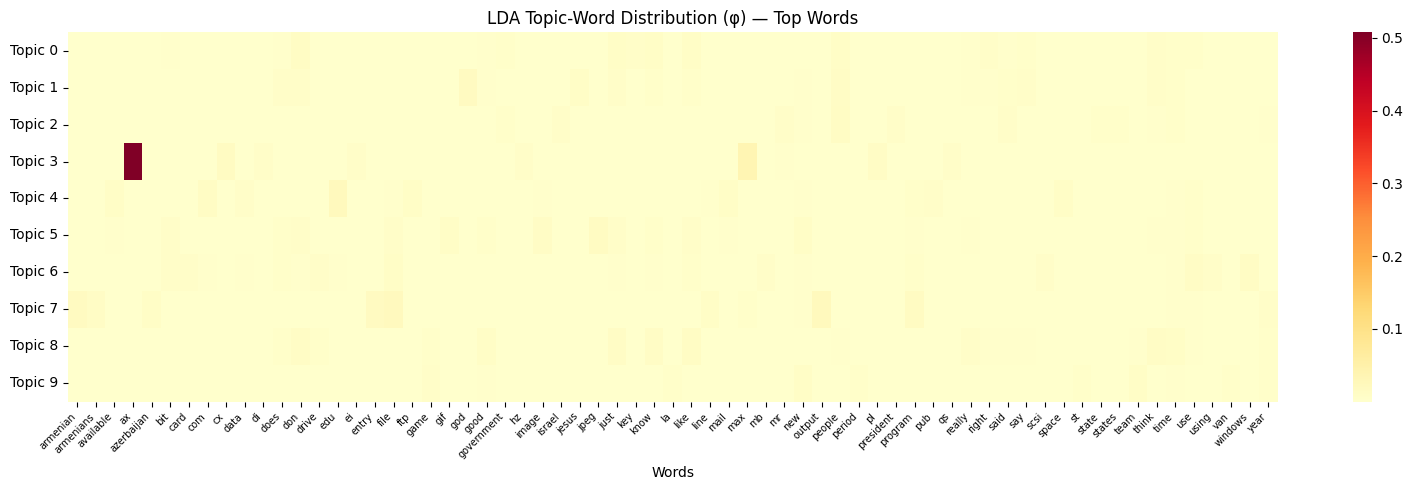

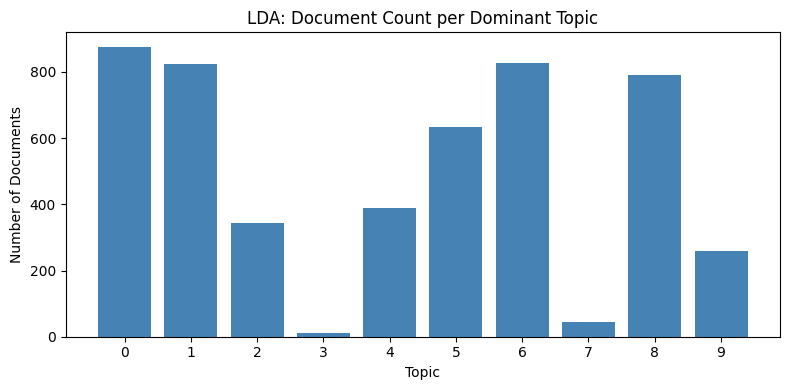

In [18]:
# === LDA Visualization ===

# ── Topic-Word Heatmap ────────────────────────────────────────────────────────
phi = lda.get_topic_word_distribution()

# Collect top 8 words per topic for display
top_n = 8
all_top_words = set()
for k in range(NUM_TOPICS):
    top_idx = phi[k].argsort()[::-1][:top_n]
    all_top_words.update(top_idx)

all_top_words = sorted(all_top_words)
top_word_labels = [idx2word[i] for i in all_top_words]

# Slice phi to only the selected words for a readable heatmap
# (num_topics, vocab_size) → (num_topics, num_selected_words)
phi_subset = phi[:, all_top_words]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    phi_subset,
    xticklabels=top_word_labels,
    yticklabels=[f"Topic {k}" for k in range(NUM_TOPICS)],
    cmap="YlOrRd",
    ax=ax,
)
ax.set_title("LDA Topic-Word Distribution (φ) — Top Words")
ax.set_xlabel("Words")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

# ── Document-Topic Bar Chart ──────────────────────────────────────────────────
theta = lda.get_document_topic_distribution()

# Assign each document to its dominant topic
# (num_docs, num_topics) → (num_docs,)
doc_topics = theta.argmax(axis=1)
topic_counts = Counter(doc_topics)

fig, ax = plt.subplots(figsize=(8, 4))
topics_sorted = sorted(topic_counts.keys())
counts_sorted = [topic_counts[k] for k in topics_sorted]
ax.bar(topics_sorted, counts_sorted, color="steelblue")
ax.set_xlabel("Topic")
ax.set_ylabel("Number of Documents")
ax.set_title("LDA: Document Count per Dominant Topic")
ax.set_xticks(topics_sorted)
plt.tight_layout()
plt.show()

# 3) BERTopic

BERTopic replaces LDA's bag-of-words assumption with **dense semantic embeddings**.
The pipeline has four stages, each solving a specific sub-problem:

```
Documents → [1. Embed] → [2. Reduce dims] → [3. Cluster] → [4. c-TF-IDF] → Topics
```

| Stage | Method | Why |
|-------|--------|-----|
| 1. Embed | Sentence-BERT | Capture semantic meaning, not just word overlap |
| 2. Reduce | UMAP | Embeddings are ~384-768 dim — too high for clustering |
| 3. Cluster | HDBSCAN | Finds clusters of varying density; doesn't force every doc into a cluster |
| 4. Represent | c-TF-IDF | Extracts interpretable keywords per cluster |

### Why Not Just Cluster Embeddings Directly?
Clustering in high-dimensional spaces suffers from the **curse of dimensionality**:
distances between points become nearly uniform, making density-based clustering
ineffective. UMAP preserves local structure while reducing to ~5 dimensions.

### c-TF-IDF (Class-based TF-IDF)
Standard TF-IDF operates at the document level. c-TF-IDF treats **all documents
in a cluster as a single mega-document**, then computes TF-IDF to find words that
are distinctive to that cluster versus the entire corpus:

$$\text{c-TF-IDF}_{k,w} = \frac{f_{k,w}}{\sum_{w'} f_{k,w'}} \cdot \log\left(\frac{N}{f_w}\right)$$

Where $f_{k,w}$ is the frequency of word $w$ in cluster $k$, and $f_w$ is the
total frequency of word $w$ across all clusters.

### Sample Input/Output
- **Input:** list of document strings
- **Output:** cluster labels `(num_docs,)`, topic keywords per cluster,
  c-TF-IDF matrix `(num_clusters, vocab_size)`


## 3.1 Sentence Embeddings

In [19]:
from sentence_transformers import SentenceTransformer

# Use all documents (not just the LDA subset)
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# (num_docs,) → (num_docs, embed_dim=384)
embeddings = embed_model.encode(
    documents, show_progress_bar=True, batch_size=128
)

print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Single embedding (first 5 dims): {embeddings[0][:5]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/142 [00:00<?, ?it/s]

Embedding matrix shape: (18072, 384)
Single embedding (first 5 dims): [ 0.00482624  0.02268012  0.01046657 -0.01373057  0.05199727]


## 3.2 UMAP Dimensionality Reduction

UMAP (Uniform Manifold Approximation and Projection) reduces the 384-dim
embeddings to 5 dimensions while preserving local neighborhood structure.

Key parameters:
- `n_neighbors=15`: controls local vs global structure preservation.
  Lower = more local detail; higher = more global structure.
- `n_components=5`: target dimensionality. 5 works well for HDBSCAN.
  (2D is for visualization only — too lossy for clustering.)
- `metric='cosine'`: matches how sentence embeddings measure similarity.

In [20]:
from umap import UMAP

# (num_docs, embed_dim=384) → (num_docs, 5)
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED,
)
reduced_embeddings = umap_model.fit_transform(embeddings)
print(f"Reduced shape: {reduced_embeddings.shape}")

# Also produce 2D for visualization
# (num_docs, embed_dim=384) → (num_docs, 2)
umap_2d = UMAP(
    n_neighbors=15, n_components=2, min_dist=0.0,
    metric="cosine", random_state=SEED
).fit_transform(embeddings)
print(f"2D projection shape: {umap_2d.shape}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (18072, 5)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D projection shape: (18072, 2)


## 3.3 HDBSCAN Clustering

HDBSCAN (Hierarchical Density-Based Spatial Clustering) finds clusters of
varying density without requiring a pre-specified number of clusters.

Key advantages over K-Means:
1. No need to specify K (number of clusters)
2. Can leave outlier documents unclustered (label = -1)
3. Handles non-spherical cluster shapes

Key parameters:
- `min_cluster_size=30`: minimum documents to form a cluster.
  Too low → noisy micro-clusters; too high → merges distinct topics.

Clusters found: 62
Outliers (label=-1): 5169 (28.6%)


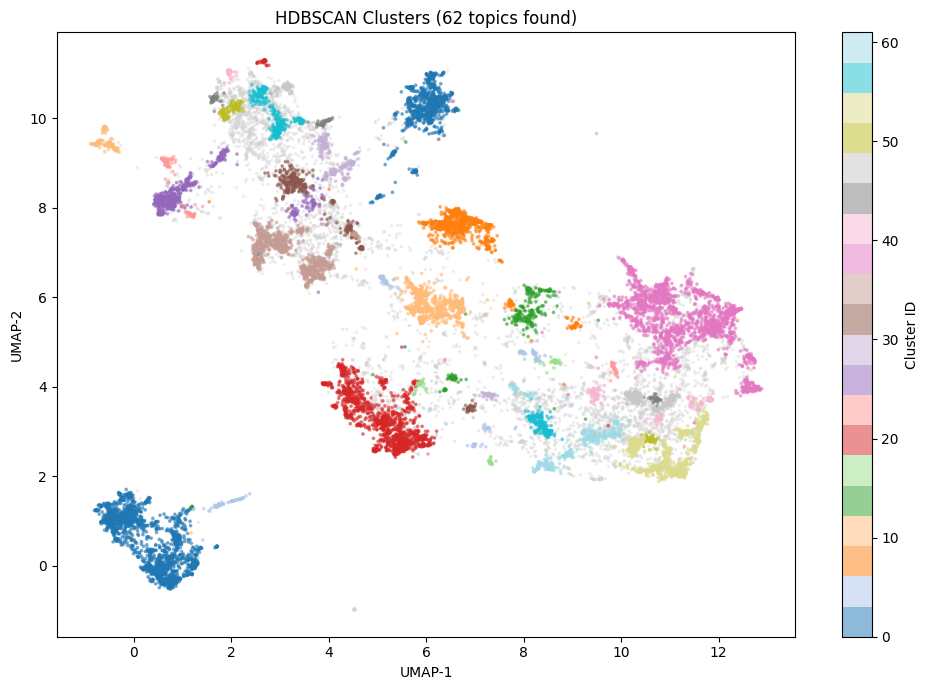

In [21]:
import hdbscan

# (num_docs, 5) → cluster_labels: (num_docs,) with values in {-1, 0, 1, ...}
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    metric="euclidean",
    cluster_selection_method="eom",
)
cluster_labels = clusterer.fit_predict(reduced_embeddings)

num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
num_outliers = (cluster_labels == -1).sum()

print(f"Clusters found: {num_clusters}")
print(f"Outliers (label=-1): {num_outliers} ({num_outliers/len(cluster_labels)*100:.1f}%)")

# ── Visualization: 2D scatter colored by cluster ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Plot outliers in light gray
outlier_mask = cluster_labels == -1
ax.scatter(
    umap_2d[outlier_mask, 0], umap_2d[outlier_mask, 1],
    c="lightgray", s=2, alpha=0.3, label="Outliers"
)

# Plot clustered documents
scatter = ax.scatter(
    umap_2d[~outlier_mask, 0], umap_2d[~outlier_mask, 1],
    c=cluster_labels[~outlier_mask], cmap="tab20", s=3, alpha=0.5
)
ax.set_title(f"HDBSCAN Clusters ({num_clusters} topics found)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.colorbar(scatter, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.show()

## 3.4 c-TF-IDF

Standard TF-IDF treats each document independently. c-TF-IDF concatenates all
documents in a cluster into a single mega-document, then computes TF-IDF.
This finds words that are distinctive to each cluster.


In [22]:
class ClassTFIDF:
    """Class-based TF-IDF for extracting topic keywords from clusters.

    Reference: Grootendorst, 2022 (Section 3.3 in the BERTopic paper).
    """

    def __init__(self, ngram_range=(1, 2), max_features=10000):
        self.vectorizer = CountVectorizer(
            ngram_range=ngram_range,
            max_features=max_features,
            stop_words="english",
        )

    def fit_transform(
        self, documents: list, labels: np.ndarray
    ) -> tuple:
        """
        Compute c-TF-IDF for each cluster.

        Args:
            documents: list of document strings
            labels: (num_docs,) cluster assignments (-1 = outlier, excluded)

        Returns:
            c_tf_idf: (num_clusters, vocab_size) — c-TF-IDF scores
            feature_names: list of vocabulary words
            cluster_ids: sorted list of cluster IDs (excluding -1)
        """
        # Get unique cluster IDs (exclude outliers)
        cluster_ids = sorted(set(labels) - {-1})

        # Concatenate all documents within each cluster into a single mega-document
        mega_docs = []
        for cid in cluster_ids:
            mask = labels == cid
            cluster_text = " ".join(
                [documents[i] for i in range(len(documents)) if mask[i]]
            )
            mega_docs.append(cluster_text)

        # Fit vocabulary on all documents, then transform mega-documents
        self.vectorizer.fit(documents)

        # Count word occurrences per mega-document
        # (num_clusters, vocab_size) — raw word counts per cluster
        count_matrix = self.vectorizer.transform(mega_docs).toarray()

        # ── TF: normalize within each cluster ─────────────────────────────
        # (num_clusters, vocab_size) / (num_clusters, 1) → (num_clusters, vocab_size)
        cluster_word_sums = count_matrix.sum(axis=1, keepdims=True)
        # Avoid division by zero for empty clusters
        cluster_word_sums = np.maximum(cluster_word_sums, 1)
        tf = count_matrix / cluster_word_sums

        # ── IDF: penalize words common across all clusters ────────────────
        # Total frequency of each word across all clusters
        # (vocab_size,)
        total_freq = count_matrix.sum(axis=0)
        total_freq = np.maximum(total_freq, 1)

        # Number of mega-documents (clusters)
        n_clusters = len(cluster_ids)

        # IDF = log(N / f_w) where N = total documents in corpus
        # (vocab_size,)
        idf = np.log(len(documents) / total_freq)

        # ── c-TF-IDF ──────────────────────────────────────────────────────
        # (num_clusters, vocab_size) * (1, vocab_size) → (num_clusters, vocab_size)
        c_tf_idf = tf * idf.reshape(1, -1)

        feature_names = self.vectorizer.get_feature_names_out()
        self.c_tf_idf_ = c_tf_idf
        self.feature_names_ = feature_names
        self.cluster_ids_ = cluster_ids

        return c_tf_idf, feature_names, cluster_ids

    def top_words_per_topic(self, n_words: int = 10) -> dict:
        """Extract top-n words per cluster based on c-TF-IDF scores.

        Returns: dict mapping cluster_id → list of (word, score) tuples
        """
        topics = {}
        for i, cid in enumerate(self.cluster_ids_):
            # Get indices of top words sorted by c-TF-IDF (descending)
            top_idx = self.c_tf_idf_[i].argsort()[::-1][:n_words]
            topics[cid] = [
                (self.feature_names_[j], self.c_tf_idf_[i, j])
                for j in top_idx
            ]
        return topics


# ── Run c-TF-IDF ──────────────────────────────────────────────────────────────
ctfidf = ClassTFIDF(ngram_range=(1, 2), max_features=10000)
c_tf_idf_matrix, features, cluster_ids = ctfidf.fit_transform(
    documents, cluster_labels
)

print(f"c-TF-IDF matrix shape: {c_tf_idf_matrix.shape}")
print(f"\n{'='*60}")
print("BERTopic (from scratch) — Topic Keywords")
print(f"{'='*60}")

scratch_topics = ctfidf.top_words_per_topic(n_words=10)
for cid, words in list(scratch_topics.items())[:15]:
    word_str = ", ".join([w for w, s in words])
    print(f"  Topic {cid:3d}: {word_str}")

c-TF-IDF matrix shape: (62, 10000)

BERTopic (from scratch) — Topic Keywords
  Topic   0: game, team, games, season, hockey, play, year, players, league, player
  Topic   1: kirlian, photography, leaf, pictures, carl, fields, object, energy, plates, sol
  Topic   2: medical, cancer, patients, disease, health, hiv, doctor, treatment, vitamin, food
  Topic   3: drugs, insurance, drug, health, private, health insurance, health care, care, canada, canadian
  Topic   4: phone, dialing, tone, hook, wires, dial, line, ring, number, wall
  Topic   5: tickets, hotel, ticket, ca, pm, package, june, vacation, room, nights
  Topic   6: water, water dept, mwra, dept, energy, phd, environmental, environment, atmospheric, atmosphere
  Topic   7: hacker, computer, japanese, engineering, hackers, programming, courses, university, language, software
  Topic   8: key, encryption, clipper, chip, keys, privacy, government, security, entry, output
  Topic   9: oo, edu, article, quoting, apr, virginia edu, c

## 3.5 BERTopic Library

The BERTopic library wraps the same pipeline into a single API.
We run it here to verify our from-scratch implementation produces
comparable results.

In [23]:
from bertopic import BERTopic

# Use same embedding model for fair comparison
topic_model = BERTopic(
    embedding_model="all-MiniLM-L6-v2",
    min_topic_size=30,
    verbose=False,
)

# Pass precomputed embeddings to avoid re-encoding
lib_topics, lib_probs = topic_model.fit_transform(documents, embeddings)

print(f"BERTopic library found {len(set(lib_topics)) - 1} topics")
print(f"\nTop 10 topics (library):")
topic_model.get_topic_info().head(11)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTopic library found 64 topics

Top 10 topics (library):


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5947,-1_ax_the_to_is,"[ax, the, to, is, of, and, max, that, in, it]",[the white house office of the press secretary...
1,0,1782,0_game_he_team_the,"[game, he, team, the, in, was, games, to, year...",[oh yeah dave winfield marginal player guy did...
2,1,1511,1_car_the_bike_it,"[car, the, bike, it, you, and, my, to, on, in]",[i ll tell you my story as an example of what ...
3,2,809,2_of_and_in_to,"[of, and, in, to, the, is, medical, it, that, ...",[cut here volume number april health info com ...
4,3,702,3_key_encryption_the_to,"[key, encryption, the, to, clipper, be, of, ch...",[begin pgp signed message please note that the...
5,4,683,4_space_the_of_launch,"[space, the, of, launch, and, to, nasa, in, on...",[archive name space controversy last modified ...
6,5,502,5_fbi_they_the_koresh,"[fbi, they, the, koresh, batf, was, fire, that...",[this was posted by lyn bates to the firearms ...
7,6,452,6_israel_israeli_jews_the,"[israel, israeli, jews, the, of, arab, to, in,...",[stuff deleted are you calling names or giving...
8,7,359,7_gun_guns_the_of,"[gun, guns, the, of, to, that, and, in, you, is]",[two questions when was this and do you have t...
9,8,347,8_window_widget_lib_the,"[window, widget, lib, the, to, application, is...",[i posted this a few weeks back but all i got ...


# 4) LLM-Enhanced Topic Labeling

Both LDA and BERTopic produce **keyword lists** as topic representations:
e.g., `["space", "nasa", "orbit", "shuttle", "launch"]`. While interpretable,
these require a human to mentally synthesize a label like "Space Exploration."

LLM-based labeling automates this: we feed representative documents and keywords
to a language model and ask it to generate a concise, human-readable topic name.

### Pipeline
```
For each topic:
  1. Select representative documents (via MMR or centroid proximity)
  2. Extract keywords (from c-TF-IDF)
  3. Prompt LLM: "Given these docs and keywords, generate a short topic label"
```

## 4.1 Maximal Marginal Relevance (MMR)

Naively picking the top-K most central documents often yields redundant content.
MMR balances **relevance** (similarity to cluster centroid) with **diversity**
(dissimilarity to already-selected documents):


$$\text{MMR} = \arg\max_{d_i \in R \setminus S} \left[ \lambda \cdot \text{sim}(d_i, C) - (1-\lambda) \cdot \max_{d_j \in S} \text{sim}(d_i, d_j) \right]$$

Where
- $C$ is the cluster centroid
- $S$ is the set of already-selected docs,
- $\lambda$ controls the relevance-diversity tradeoff

In [24]:
def select_representative_docs_mmr(
    doc_embeddings: np.ndarray,
    doc_indices: np.ndarray,
    n_docs: int = 5,
    diversity: float = 0.5,
) -> list:
    """
    Select diverse, representative documents from a cluster using MMR.

    Args:
        doc_embeddings: (num_cluster_docs, embed_dim) — embeddings of docs in this cluster
        doc_indices: (num_cluster_docs,) — original indices into the full document list
        n_docs: number of representative documents to select
        diversity: lambda in [0, 1]. 0 = max diversity, 1 = max relevance.

    Returns:
        list of original document indices selected by MMR
    """
    # Compute cluster centroid
    # (num_cluster_docs, embed_dim) → (1, embed_dim)
    centroid = doc_embeddings.mean(axis=0, keepdims=True)

    # Similarity of each doc to the centroid
    # (num_cluster_docs, embed_dim) × (embed_dim, 1) → (num_cluster_docs,)
    centroid_sim = cosine_similarity(doc_embeddings, centroid).flatten()

    # Pairwise similarity between all docs in the cluster
    # (num_cluster_docs, embed_dim) → (num_cluster_docs, num_cluster_docs)
    pair_sim = cosine_similarity(doc_embeddings)

    # Start with the most central document
    selected = [int(np.argmax(centroid_sim))]
    candidates = list(range(len(doc_embeddings)))
    candidates.remove(selected[0])

    # Iteratively select using MMR
    for _ in range(min(n_docs - 1, len(candidates))):
        # Relevance: similarity to centroid for each candidate
        # (num_candidates,)
        relevance = centroid_sim[candidates]

        # Redundancy: max similarity to any already-selected doc
        # (num_candidates, num_selected) → (num_candidates,)
        redundancy = pair_sim[np.ix_(candidates, selected)].max(axis=1)

        # MMR score
        # (num_candidates,)
        mmr_scores = diversity * relevance - (1 - diversity) * redundancy

        # Select the candidate with highest MMR
        best_idx = candidates[int(np.argmax(mmr_scores))]
        selected.append(best_idx)
        candidates.remove(best_idx)

    # Map local indices back to global document indices
    return [int(doc_indices[i]) for i in selected]


# ── Select representatives for each cluster ────────────────────────────────────
cluster_representatives = {}
for cid in cluster_ids[:15]:
    mask = cluster_labels == cid
    indices = np.where(mask)[0]
    cluster_embeds = embeddings[mask]

    rep_indices = select_representative_docs_mmr(
        cluster_embeds, indices, n_docs=5, diversity=0.5
    )
    cluster_representatives[cid] = rep_indices

# Show representatives for topic 0
print("Topic 0 — Representative documents (via MMR):")
for idx in cluster_representatives.get(0, []):
    print(f"  [{idx}] {documents[idx][:100]}...")

Topic 0 — Representative documents (via MMR):
  [5813] never was probably is not now debatable what other valid test can you think of besides the final sta...
  [4819] first a longer game in no way suggests more baseball to watch unless you include watching the grass ...
  [5344] philadelphia at chicago teams tied for st after sunday dick redding battled chet brewer in the first...
  [6795] i m from dallas and you have alot of nerve saying that wfan has a bunch of hoodlum mets fans during ...
  [15585] cdash moet cs colorado edu charles shub writes what really irritated me was that they kept switching...


## 4.2 Topic Labeling

We construct a prompt with:
1. Top keywords from c-TF-IDF
2. Representative documents selected via MMR

The LLM generates a short, descriptive topic label.

In [25]:
client = openai.OpenAI()

def build_labeling_prompt(
    keywords: list, representative_docs: list, max_doc_chars: int = 300
) -> str:
    """
    Construct a topic labeling prompt.

    Args:
        keywords: list of (word, score) tuples from c-TF-IDF
        representative_docs: list of document strings
        max_doc_chars: truncation limit per document

    Returns:
        Formatted prompt string for the LLM
    """
    kw_str = ", ".join([w for w, s in keywords[:10]])

    doc_str = "\n".join(
        [f"- {doc[:max_doc_chars]}" for doc in representative_docs]
    )

    prompt = (
        "I have a topic from a topic model that contains the following documents:\n"
        f"{doc_str}\n\n"
        f"The topic is described by these keywords: {kw_str}\n\n"
        "Based on the documents and keywords above, generate a short, "
        "descriptive label for this topic (3-6 words). "
        "Return ONLY the label, nothing else."
    )
    return prompt


def label_topics_with_llm(
    topic_keywords: dict,
    cluster_representatives: dict,
    documents: list,
) -> dict:
    """
    Generate topic labels using an LLM.

    Falls back to keyword-based labeling if no API key is provided.

    Args:
        topic_keywords: dict mapping cluster_id → list of (word, score)
        cluster_representatives: dict mapping cluster_id → list of doc indices
        documents: full document list

    Returns:
        dict mapping cluster_id → label string
    """
    labels = {}

    for cid in topic_keywords:
        if cid not in cluster_representatives:
            continue

        keywords = topic_keywords[cid]
        rep_docs = [documents[i] for i in cluster_representatives[cid]]
        prompt = build_labeling_prompt(keywords, rep_docs)

        response = client.chat.completions.create(
            model="gpt-5-mini",
            messages=[{"role": "user", "content": prompt}],
        )
        labels[cid] = response.choices[0].message.content.strip()
    else:
        # Fallback: use top 3 keywords as a crude label
        labels[cid] = " / ".join([w for w, s in keywords[:3]])

    return labels


# ── Generate Labels ────────────────────────────────────────────────────────────
topic_labels = label_topics_with_llm(
    scratch_topics, cluster_representatives, documents
)

for cid, label in list(topic_labels.items())[:15]:
    kw = ", ".join([w for w, s in scratch_topics[cid][:5]])
    print(f"  Topic {cid:3d}: {label}")
    print(f"            keywords: {kw}\n")

# Show the prompt for one topic so students see the structure
sample_cid = cluster_ids[0]
sample_prompt = build_labeling_prompt(
    scratch_topics[sample_cid],
    [documents[i] for i in cluster_representatives[sample_cid]],
)
print(f"\n{'='*60}")
print(f"Sample prompt for Topic {sample_cid}:")
print(f"{'='*60}")
print(sample_prompt[:600])

  Topic   0: Baseball and Hockey Discussions
            keywords: game, team, games, season, hockey

  Topic   1: Kirlian photography explanations
            keywords: kirlian, photography, leaf, pictures, carl

  Topic   2: Medical treatments, nutrition, and patients
            keywords: medical, cancer, patients, disease, health

  Topic   3: Drug policy and health insurance
            keywords: drugs, insurance, drug, health, private

  Topic   4: Telephone dialing and wiring
            keywords: phone, dialing, tone, hook, wires

  Topic   5: Tickets, travel and accommodations
            keywords: tickets, hotel, ticket, ca, pm

  Topic   6: Environmental, water, and energy policy
            keywords: water, water dept, mwra, dept, energy

  Topic   7: Computer Programming and University Courses
            keywords: hacker, computer, japanese, engineering, hackers

  Topic   8: Government encryption and key escrow
            keywords: key, encryption, clipper, chip, keys



# 5) LLM-Native Topic Discovery


Traditional topic modeling follows a multi-stage pipeline:
```
Documents → Embeddings → Dim Reduction → Clustering → Keyword Extraction → (optional) LLM Label
```

LLM-native topic discovery collapses this entire pipeline into direct LLM calls:
```
Documents → LLM → Topics
```

### Why This Works Now (But Didn't Before)
1. **Context windows are large enough.** GPT-4o handles 128K tokens — you can fit
   hundreds of documents in a single prompt.
2. **Structured outputs** guarantee valid JSON responses, eliminating brittle parsing.
3. **Cost has dropped.** GPT-4o-mini at $0.15/1M input tokens makes corpus-scale
   processing feasible.

### The Core Idea
Instead of learning latent topics from word co-occurrence (LDA) or cluster structure
(BERTopic), we leverage the LLM's pre-trained world knowledge to directly:
1. **Discover** — "What themes appear in these documents?"
2. **Consolidate** — "Merge similar themes across batches into a canonical list."
3. **Assign** — "Which topic does each document belong to?"

### Why Not Just Send the Whole Corpus?
Even with 128K context, a corpus of 18K documents won't fit. We use a
**sample-then-generalize** strategy:
1. Process a representative sample in batches
2. Extract candidate topics from each batch
3. Merge duplicates into a final topic taxonomy
4. Classify the full corpus against the discovered topics

## 5.1 Topic Discovery via Batched Prompting


We sample a subset of documents, split them into batches, and ask the LLM
to identify themes in each batch. The key prompt design choices:

1. **Batch size = 20-30 docs**: Large enough to surface patterns, small enough
   to fit comfortably in context with the full document text.
2. **Ask for 3-8 topics per batch**: Prevents the LLM from either over-splitting
   (one topic per doc) or under-splitting (one giant topic).
3. **Structured output**: We request JSON with a specific schema to avoid
   parsing failures.
4. **Include document text, not just titles**: The LLM needs actual content
   to identify nuanced themes.

### Prompt Structure
```
System: You are a topic modeling expert. Analyze documents and extract themes.
User:   Here are {n} documents. Identify 3-8 distinct topics.
        Return JSON: {"topics": [{"name": "...", "description": "...", "doc_indices": [...]}]}
```

In [26]:
MODEL = "gpt-4o-mini"

def create_discovery_prompt(doc_batch: list, batch_indices: list) -> list:
    """
    Build the chat messages for topic discovery on a single batch.

    Args:
        doc_batch: list of document strings (will be truncated to 500 chars each)
        batch_indices: list of integer indices for reference in output

    Returns:
        list of message dicts for the OpenAI chat API
    """
    system_msg = (
        "You are a topic modeling expert. Your task is to read a batch of "
        "documents and identify the distinct topics or themes present.\n\n"
        "Rules:\n"
        "- Identify between 3 and 8 topics\n"
        "- Each topic needs a short name (2-5 words) and a one-sentence description\n"
        "- Assign each document to exactly one topic\n"
        "- Topic names should be specific and descriptive, not generic "
        "(e.g. 'Computer Graphics Hardware' not 'Technology')\n"
        "- Every document must be assigned to a topic\n"
        "- Return ONLY valid JSON, no other text"
    )

    # Format documents with local indices for reference
    doc_text = "\n\n".join(
        [f"[Doc {i}]: {doc[:500]}" for i, doc in enumerate(doc_batch)]
    )

    user_msg = (
        f"Here are {len(doc_batch)} documents. Identify the distinct topics.\n\n"
        f"{doc_text}\n\n"
        'Return JSON with this exact schema:\n'
        '{\n'
        '  "topics": [\n'
        '    {\n'
        '      "name": "Short Topic Name",\n'
        '      "description": "One sentence describing what this topic covers",\n'
        '      "doc_indices": [0, 3, 7]\n'
        '    }\n'
        '  ]\n'
        '}'
    )

    return [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

def discover_topics_batch(
    documents: list,
    sample_size: int = 300,
    batch_size: int = 25,
    model: str = MODEL,
) -> list:
    """
    Discover topics by processing document batches through an LLM.

    Strategy: sample a representative subset, split into batches, extract
    themes from each batch independently. Later stages consolidate duplicates.

    Args:
        documents: full document list
        sample_size: number of documents to sample for discovery
        batch_size: documents per LLM call
        model: OpenAI model identifier

    Returns:
        list of dicts, each with keys: name, description, doc_indices,
        global_doc_indices, batch_id
    """
    # Random sample for discovery
    sample_indices = random.sample(
        range(len(documents)), min(sample_size, len(documents))
    )
    sample_docs = [documents[i] for i in sample_indices]

    # Split into batches
    batches = []
    for i in range(0, len(sample_docs), batch_size):
        batch_docs = sample_docs[i : i + batch_size]
        batch_global_indices = sample_indices[i : i + batch_size]
        batches.append((batch_docs, batch_global_indices))

    print(f"Discovery: {len(sample_docs)} sampled docs → {len(batches)} batches of ~{batch_size}")

    all_topics = []
    for batch_id, (batch_docs, batch_global_indices) in enumerate(batches):
        messages = create_discovery_prompt(batch_docs, batch_global_indices)

        # Call LLM with structured JSON output
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=0.2,
            max_tokens=2000,
            response_format={"type": "json_object"},
        )

        raw = response.choices[0].message.content
        result = json.loads(raw)

        # Extract topics and enrich with batch metadata
        for topic in result.get("topics", []):
            topic["batch_id"] = batch_id

            # Map local doc indices back to global corpus indices
            local_indices = topic.get("doc_indices", [])
            topic["global_doc_indices"] = [
                int(batch_global_indices[i])
                for i in local_indices
                if i < len(batch_global_indices)
            ]
            all_topics.append(topic)

        # Print progress
        batch_topic_names = [t["name"] for t in result.get("topics", [])]
        print(
            f"  Batch {batch_id + 1:2d}/{len(batches)} → "
            f"{len(batch_topic_names)} topics: {batch_topic_names}"
        )

        # Rate limit: gpt-4o-mini allows ~500 RPM but be courteous
        time.sleep(0.3)

    print(
        f"\n✅ Discovery complete: {len(all_topics)} candidate topics "
        f"from {len(batches)} batches"
    )
    return all_topics

In [27]:
candidate_topics = discover_topics_batch(
    documents, sample_size=300, batch_size=25, model=MODEL
)

# Show all candidates grouped by batch
print(f"\nAll {len(candidate_topics)} candidate topics:")
for t in candidate_topics:
    print(f"  [Batch {t['batch_id']:2d}] {t['name']}: {t.get('description', '')[:80]}")


Discovery: 300 sampled docs → 12 batches of ~25
  Batch  1/12 → 8 topics: ['Neural Networks and Shape Analysis', 'Dreams and Morality', 'Food Allergies and Reactions', 'Image File Conversion', 'Used Equipment Market', 'Computer Hardware Issues', 'Astronomy and Space Exploration', 'Social and Political Commentary']
  Batch  2/12 → 13 topics: ['Navy Tattoos and Masculinity', 'Graphics Card Issues', 'Smoking and Addiction', 'Rapture and End Times', 'Political and Space Funding', 'Dietary Choices and Health', 'Human Rights Violations', 'Automotive Technology Discussion', 'Elderly Hospitalization Effects', 'Media and Sports Broadcasting', 'Computer Equipment Design', 'Driving Laws and Penalties', 'Community Engagement and Sports']
  Batch  3/12 → 8 topics: ['Human Endurance and Geology', 'Philosophy of Afterlife', 'Gun Control and Threat Perception', 'Home Medical Testing', 'Computer Hardware Queries', 'Political and Social Commentary', 'Sports Analysis and Predictions', 'Consumer Electroni

## 5.2  Topic Consolidation via LLM

- Different batches independently discover similar topics.
- For example, batch 1 might find "Space & NASA" while batch 5 finds "Space Exploration."
We need to merge these into a canonical taxonomy.

### Approach: LLM-Based Merging
Pass all candidate topic names and descriptions to the LLM and ask it to:
1. Identify groups of duplicate/near-duplicate topics
2. Choose the best name for each group
3. Produce a clean, deduplicated taxonomy of 8-20 canonical topics

This is more accurate than embedding-based merging for nuanced distinctions
(e.g., "Gun Control Policy" vs "Firearms Technology" — similar embeddings
but genuinely different topics that should NOT be merged).

### Why 8-20 Topics?
- Fewer than 8 forces the LLM to over-merge distinct themes
- More than 20 becomes hard to evaluate and compare with other methods
- 20 Newsgroups has 20 true categories, so this range is well-calibrated

In [28]:

def consolidate_topics(
    candidate_topics: list, model: str = MODEL
) -> list:
    """
    Merge duplicate candidate topics into a canonical taxonomy using the LLM.

    Args:
        candidate_topics: list of topic dicts with 'name' and 'description'
        model: OpenAI model identifier

    Returns:
        list of canonical topic dicts with 'name', 'description'
    """
    # Format all candidates for the prompt
    topic_list = "\n".join(
        [
            f"{i+1}. {t['name']}: {t.get('description', 'No description')}"
            for i, t in enumerate(candidate_topics)
        ]
    )

    messages = [
        {
            "role": "system",
            "content": (
                "You are a taxonomy expert. Given a list of candidate topics "
                "extracted from different document batches, produce a clean, "
                "deduplicated list of canonical topics.\n\n"
                "Rules:\n"
                "- Merge topics that refer to the same or very similar theme\n"
                "- Do NOT merge topics that are related but genuinely distinct "
                "(e.g., 'Baseball' and 'Hockey' are both sports but should stay separate)\n"
                "- Keep names specific and descriptive (2-5 words)\n"
                "- Provide a one-sentence description for each\n"
                "- Aim for 8-20 final topics\n"
                "- For each final topic, list which input topic numbers were merged into it\n"
                "- Return ONLY valid JSON"
            ),
        },
        {
            "role": "user",
            "content": (
                f"Here are {len(candidate_topics)} candidate topics extracted "
                f"from different batches of documents:\n\n"
                f"{topic_list}\n\n"
                "Merge duplicates and produce a canonical taxonomy.\n\n"
                "JSON schema:\n"
                '{\n'
                '  "topics": [\n'
                '    {\n'
                '      "name": "Canonical Topic Name",\n'
                '      "description": "One sentence description",\n'
                '      "merged_from": [1, 5, 12]\n'
                '    }\n'
                '  ]\n'
                '}'
            ),
        },
    ]

    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
        max_tokens=4000,
        response_format={"type": "json_object"},
    )

    result = json.loads(response.choices[0].message.content)
    return result.get("topics", [])

In [29]:
consolidated_topics = consolidate_topics(candidate_topics, model=MODEL)
print(f"✅ Consolidated {len(candidate_topics)} candidates → {len(consolidated_topics)} canonical topics:\n")
for i, t in enumerate(consolidated_topics):
    merged = t.get("merged_from", [])
    merged_str = f" ← merged from candidates {merged}" if merged else ""
    print(f"  {i:2d}. {t['name']}")
    print(f"      {t.get('description', '')}")
    print(f"      {merged_str}\n")

✅ Consolidated 107 candidates → 25 canonical topics:

   0. Neural Networks and Shape Analysis
      This topic covers advancements and discussions related to neural networks specifically in the context of shape analysis.
       ← merged from candidates [1]

   1. Dreams and Morality
      This topic explores the ethical implications of actions taken in dreams and out-of-body experiences.
       ← merged from candidates [2]

   2. Food Allergies and Reactions
      This topic discusses personal experiences and inquiries related to food allergies, particularly reactions to MSG.
       ← merged from candidates [3]

   3. Image File Conversion
      This topic involves technical discussions on converting image file formats and manipulating pixel data.
       ← merged from candidates [4]

   4. Used Equipment Market
      This topic focuses on buying and selling used electronic and computing equipment.
       ← merged from candidates [5]

   5. Computer Hardware Issues
      This topic add

Now we have a canonical topic list. The final step is classifying every document
in the corpus against this taxonomy.

**Approach A — Embedding-based (scalable):**

**Approach B — LLM-based batched classification (accurate):**


## 5.3 Embedding-Based Assignment
- Embed the topic descriptions and all documents.
- Assign each document to the
most similar topic via cosine similarity.
- Cost: ~$0.01 for embeddings, zero
per-document API calls. Scales to millions of documents.

In [30]:
def assign_topics_embedding(
    documents: list,
    topic_list: list,
    doc_embeddings: np.ndarray = None,
) -> tuple:
    """
    Assign topics to all documents using embedding cosine similarity.

    For each document, computes similarity against all topic descriptions
    and assigns the highest-scoring topic.

    Args:
        documents: list of document strings
        topic_list: list of topic dicts with 'name' and 'description'
        doc_embeddings: precomputed (num_docs, embed_dim). Computed if None.

    Returns:
        assignments: (num_docs,) integer array of topic indices
        confidences: (num_docs,) float array of cosine similarity scores
    """
    from sentence_transformers import SentenceTransformer

    embed_model = SentenceTransformer("all-MiniLM-L6-v2")

    # Embed topic names + descriptions
    topic_texts = [f"{t['name']}: {t.get('description', '')}" for t in topic_list]
    # (num_topics, embed_dim=384)
    topic_embeddings = embed_model.encode(topic_texts)

    # Reuse precomputed document embeddings if available
    if doc_embeddings is None:
        # (num_docs, embed_dim=384)
        doc_embeddings = embed_model.encode(
            documents, show_progress_bar=True, batch_size=128
        )

    # Cosine similarity: each doc against each topic
    # (num_docs, embed_dim) × (embed_dim, num_topics) → (num_docs, num_topics)
    similarities = cosine_similarity(doc_embeddings, topic_embeddings)

    # Assign to highest-scoring topic
    # (num_docs, num_topics) → (num_docs,)
    assignments = similarities.argmax(axis=1)

    # Confidence = max similarity score
    # (num_docs, num_topics) → (num_docs,)
    confidences = similarities.max(axis=1)

    return assignments, confidences

In [31]:
embed_assignments, embed_confidences = assign_topics_embedding(
    documents, consolidated_topics, doc_embeddings=None
)
embed_topic_names = [consolidated_topics[i]["name"] for i in embed_assignments]

# Distribution
embed_counts = Counter(embed_topic_names)
print(f"\n✅ Embedding-based assignment: {len(documents)} docs → {len(consolidated_topics)} topics\n")
print(f"{'Topic':<40s} {'Count':>6s} {'%':>6s}")
print("-" * 54)
for topic, count in embed_counts.most_common():
    pct = count / len(documents) * 100
    print(f"  {topic:<38s} {count:5d}  {pct:5.1f}%")
print(f"\nConfidence — mean: {embed_confidences.mean():.3f}, "
      f"min: {embed_confidences.min():.3f}, max: {embed_confidences.max():.3f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/142 [00:00<?, ?it/s]


✅ Embedding-based assignment: 18072 docs → 25 topics

Topic                                     Count      %
------------------------------------------------------
  Computer Hardware Issues                2230   12.3%
  Used Equipment Market                   1612    8.9%
  Media and Sports Broadcasting           1540    8.5%
  Cryptography and Security Concerns      1356    7.5%
  Image File Conversion                   1151    6.4%
  Automotive Technology Discussion        1054    5.8%
  Social and Political Commentary         1009    5.6%
  Human Rights Violations                  999    5.5%
  Astronomy and Space Exploration          884    4.9%
  Gun Control and Crime Rates              774    4.3%
  Technical Challenges in Computing        742    4.1%
  Philosophy of Afterlife                  697    3.9%
  Driving Laws and Penalties               649    3.6%
  Smoking and Addiction                    533    2.9%
  Rapture and End Times                    454    2.5%
  Food All

## 5.4 LLM-Based Batched Assignment

- Send documents in batches of 20-30 with the full topic list.
- The LLM assigns
each document to a topic.
- More accurate for ambiguous documents but costs
~$0.50-2.00 for 18K documents.

In [32]:

def assign_topics_llm(
    documents: list,
    doc_indices: list,
    topic_list: list,
    batch_size: int = 20,
    model: str = MODEL,
) -> dict:
    """
    Assign topics to documents using batched LLM calls.

    Args:
        documents: full document list
        doc_indices: which document indices to classify
        topic_list: list of topic dicts with 'name'
        batch_size: documents per API call
        model: OpenAI model identifier

    Returns:
        dict mapping doc_index → assigned topic name
    """
    topic_names = [t["name"] for t in topic_list]
    topic_list_str = "\n".join([f"- {name}" for name in topic_names])

    assignments = {}

    # Process in batches
    for batch_start in range(0, len(doc_indices), batch_size):
        batch_indices = doc_indices[batch_start : batch_start + batch_size]
        batch_docs = [documents[i] for i in batch_indices]

        doc_text = "\n\n".join(
            [f"[Doc {i}]: {doc[:400]}" for i, doc in zip(batch_indices, batch_docs)]
        )

        messages = [
            {
                "role": "system",
                "content": (
                    "You are a document classifier. Assign each document to exactly "
                    "one topic from the provided list. Choose the BEST matching topic.\n"
                    "Return ONLY valid JSON."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Topics:\n{topic_list_str}\n\n"
                    f"Documents:\n{doc_text}\n\n"
                    "Assign each document to its best matching topic.\n"
                    'JSON schema: {"assignments": [{"doc_id": 123, "topic": "Topic Name"}, ...]}'
                ),
            },
        ]

        response = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=0,
            max_tokens=2000,
            response_format={"type": "json_object"},
        )
        result = json.loads(response.choices[0].message.content)

        for entry in result.get("assignments", []):
            doc_id = entry.get("doc_id")
            topic = entry.get("topic", "")
            # Validate that the returned topic exists in our list
            if topic not in topic_names:
                # Fuzzy match: find closest topic name
                topic = min(
                    topic_names,
                    key=lambda t: abs(len(t) - len(topic))
                )
            assignments[doc_id] = topic

        time.sleep(0.3)

    return assignments

In [33]:
LLM_SAMPLE_SIZE = 200
llm_sample_indices = random.sample(range(len(documents)), LLM_SAMPLE_SIZE)

print(f"Running LLM-based assignment on {LLM_SAMPLE_SIZE} sample documents...")
llm_assignments_dict = assign_topics_llm(
    documents, llm_sample_indices, consolidated_topics, batch_size=20, model=MODEL
)

# Compare embedding vs LLM assignments on the sample
agreement = 0
for idx in llm_sample_indices:
    embed_topic = consolidated_topics[embed_assignments[idx]]["name"]
    llm_topic = llm_assignments_dict.get(idx, "")
    if embed_topic == llm_topic:
        agreement += 1

agreement_pct = agreement / LLM_SAMPLE_SIZE * 100
print(f"\n✅ Embedding vs LLM agreement on {LLM_SAMPLE_SIZE} docs: {agreement}/{LLM_SAMPLE_SIZE} ({agreement_pct:.1f}%)")
print("   (>70% agreement suggests embedding-based assignment is reliable for this corpus)")

Running LLM-based assignment on 200 sample documents...

✅ Embedding vs LLM agreement on 200 docs: 88/200 (44.0%)
   (>70% agreement suggests embedding-based assignment is reliable for this corpus)


# 6) Evaluation

## 6.1 Topic Coherence
Measures whether the top words in a topic **co-occur** in the corpus, which
correlates with human judgments of topic quality.

**NPMI (Normalized Pointwise Mutual Information):**
$$\text{NPMI}(w_i, w_j) = \frac{\log \frac{p(w_i, w_j)}{p(w_i) \cdot p(w_j)}}{-\log p(w_i, w_j)}$$

Where:
- $p(w_i)$ = fraction of documents containing word $w_i$
- $p(w_i, w_j)$ = fraction of documents containing **both** $w_i$ and $w_j$
- NPMI ranges from -1 (never co-occur) to +1 (always co-occur)

Topic coherence = average NPMI across all pairs of top-N words in a topic.

In [34]:
class TopicCoherenceNPMI:
    """NPMI-based topic coherence computed over a reference corpus.

    For each topic, we compute pairwise NPMI between the top-N words
    and average the scores. Higher = more coherent.

    """

    def __init__(self, documents: list, vocab: set = None):
        """
        Pre-compute word occurrence statistics from the reference corpus.

        Args:
            documents: list of document strings (the reference corpus)
            vocab: optional set of words to track (default: all words)
        """
        self.n_docs = len(documents)

        # Convert each document to a set of unique words for co-occurrence
        self.doc_word_sets = [set(doc.split()) for doc in documents]

        # Count documents containing each word
        # {word: count_of_docs_containing_word}
        self.word_doc_count = Counter()
        for word_set in self.doc_word_sets:
            for word in word_set:
                if vocab is None or word in vocab:
                    self.word_doc_count[word] += 1

    def _co_occurrence_count(self, w1: str, w2: str) -> int:
        """Count documents containing both w1 and w2."""
        count = 0
        for word_set in self.doc_word_sets:
            if w1 in word_set and w2 in word_set:
                count += 1
        return count

    def _npmi(self, w1: str, w2: str, epsilon: float = 1e-12) -> float:
        """
        Compute NPMI between two words.

        NPMI(w1, w2) = log(p(w1,w2) / (p(w1)*p(w2))) / (-log(p(w1,w2)))

        Returns: float in [-1, 1]
        """
        # Marginal probabilities
        p_w1 = self.word_doc_count.get(w1, 0) / self.n_docs
        p_w2 = self.word_doc_count.get(w2, 0) / self.n_docs

        # Joint probability
        co_count = self._co_occurrence_count(w1, w2)
        p_joint = co_count / self.n_docs

        # Handle edge cases
        if p_joint < epsilon or p_w1 < epsilon or p_w2 < epsilon:
            return -1.0

        # PMI = log(p(w1,w2) / (p(w1)*p(w2)))
        pmi = np.log(p_joint / (p_w1 * p_w2))

        # Normalize by -log(p(w1,w2))
        npmi = pmi / (-np.log(p_joint))

        return float(npmi)

    def score_topic(self, topic_words: list) -> float:
        """
        Compute average pairwise NPMI for a list of topic words.

        Args:
            topic_words: list of word strings (top-N words for one topic)

        Returns:
            float — average NPMI across all unique pairs
        """
        pairs = []
        for i in range(len(topic_words)):
            for j in range(i + 1, len(topic_words)):
                pairs.append(self._npmi(topic_words[i], topic_words[j]))

        if not pairs:
            return 0.0
        return float(np.mean(pairs))

    def score_all(self, all_topic_words: dict, top_n: int = 10) -> dict:
        """
        Compute coherence for each topic.

        Args:
            all_topic_words: dict mapping topic_id → list of (word, score)
            top_n: number of top words to use per topic

        Returns:
            dict mapping topic_id → NPMI coherence score
        """
        scores = {}
        for tid, words in all_topic_words.items():
            word_list = [w for w, s in words[:top_n]]
            scores[tid] = self.score_topic(word_list)
        return scores

## 6.2 Topic Diversity
Measures how **unique** the topics are. If all topics share the same top words,
the model is degenerate.

$$\text{Diversity} = \frac{|\text{unique top words across all topics}|}{K \times N}$$

Where $K$ = number of topics, $N$ = number of top words per topic.
Diversity = 1.0 means no overlap; diversity → 0 means all topics are identical.

In [35]:
def topic_diversity(all_topic_words: dict, top_n: int = 10) -> float:
    """
    Compute topic diversity: fraction of unique words in the top-N across all topics.

    Diversity = |unique_words| / (K * N)

    Args:
        all_topic_words: dict mapping topic_id → list of (word, score)
        top_n: number of top words per topic

    Returns:
        float in [0, 1]. 1.0 = perfectly diverse, 0.0 = all topics identical.
    """
    all_words = []
    for tid, words in all_topic_words.items():
        all_words.extend([w for w, s in words[:top_n]])

    unique_count = len(set(all_words))
    total_count = len(all_words)

    if total_count == 0:
        return 0.0

    return unique_count / total_count

## 6.3 Comparison

In [36]:
# ── Build coherence scorer ─────────────────────────────────────────────────────
# Use the full LDA subset as reference corpus for fair comparison
print("Computing word co-occurrence statistics...")
coherence_scorer = TopicCoherenceNPMI(lda_documents)

# ── Evaluate LDA ──────────────────────────────────────────────────────────────
lda_topic_words = lda.top_words(n_words=10)
lda_coherence = coherence_scorer.score_all(lda_topic_words, top_n=10)
lda_diversity = topic_diversity(lda_topic_words, top_n=10)

print("\n" + "=" * 60)
print("LDA (Gibbs Sampling) — Evaluation")
print("=" * 60)
for tid, score in lda_coherence.items():
    words = ", ".join([w for w, s in lda_topic_words[tid][:5]])
    print(f"  Topic {tid:2d} | NPMI: {score:.4f} | {words}")
print(f"  {'─'*50}")
print(f"  Avg Coherence (NPMI): {np.mean(list(lda_coherence.values())):.4f}")
print(f"  Diversity:            {lda_diversity:.4f}")

# ── Evaluate BERTopic (from scratch) ──────────────────────────────────────────
bt_coherence = coherence_scorer.score_all(scratch_topics, top_n=10)
bt_diversity = topic_diversity(scratch_topics, top_n=10)

print("\n" + "=" * 60)
print("BERTopic (from scratch) — Evaluation")
print("=" * 60)
for tid, score in list(bt_coherence.items())[:10]:
    words = ", ".join([w for w, s in scratch_topics[tid][:5]])
    print(f"  Topic {tid:2d} | NPMI: {score:.4f} | {words}")
print(f"  {'─'*50}")
print(f"  Avg Coherence (NPMI): {np.mean(list(bt_coherence.values())):.4f}")
print(f"  Diversity:            {bt_diversity:.4f}")

Computing word co-occurrence statistics...

LDA (Gibbs Sampling) — Evaluation
  Topic  0 | NPMI: 0.1925 | don, people, just, like, know
  Topic  1 | NPMI: 0.2201 | god, people, jesus, does, think
  Topic  2 | NPMI: 0.3057 | people, president, said, israel, mr
  Topic  3 | NPMI: 0.6032 | ax, max, cx, pl, hz
  Topic  4 | NPMI: 0.2969 | edu, com, available, ftp, space
  Topic  5 | NPMI: 0.1540 | jpeg, image, new, gif, bit
  Topic  6 | NPMI: 0.2465 | windows, use, file, card, mb
  Topic  7 | NPMI: 0.0002 | output, file, entry, armenian, program
  Topic  8 | NPMI: 0.1839 | like, just, don, know, think
  Topic  9 | NPMI: 0.2614 | team, new, game, period, year
  ──────────────────────────────────────────────────
  Avg Coherence (NPMI): 0.2465
  Diversity:            0.8300

BERTopic (from scratch) — Evaluation
  Topic  0 | NPMI: 0.4031 | game, team, games, season, hockey
  Topic  1 | NPMI: -0.1517 | kirlian, photography, leaf, pictures, carl
  Topic  2 | NPMI: 0.3597 | medical, cancer, patien